   Serial No.  GRE Score  TOEFL Score  University Rating  SOP  LOR   CGPA  \
0           1        337          118                  4  4.5   4.5  9.65   
1           2        324          107                  4  4.0   4.5  8.87   
2           3        316          104                  3  3.0   3.5  8.00   
3           4        322          110                  3  3.5   2.5  8.67   
4           5        314          103                  2  2.0   3.0  8.21   

   Research  Chance of Admit   
0         1              0.92  
1         1              0.76  
2         1              0.72  
3         1              0.80  
4         0              0.65  
(400, 9)
Serial No.           0
GRE Score            0
TOEFL Score          0
University Rating    0
SOP                  0
LOR                  0
CGPA                 0
Research             0
Chance of Admit      0
dtype: int64
0


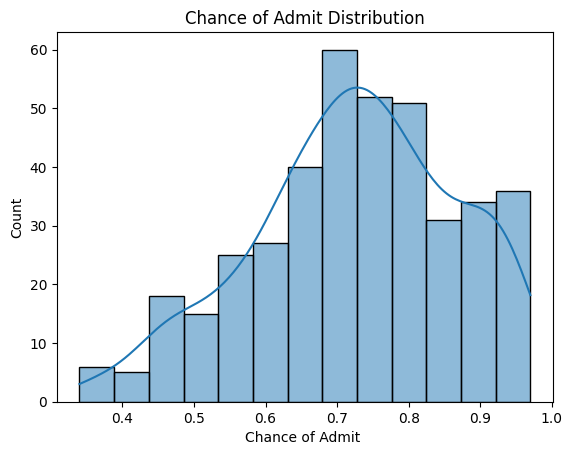

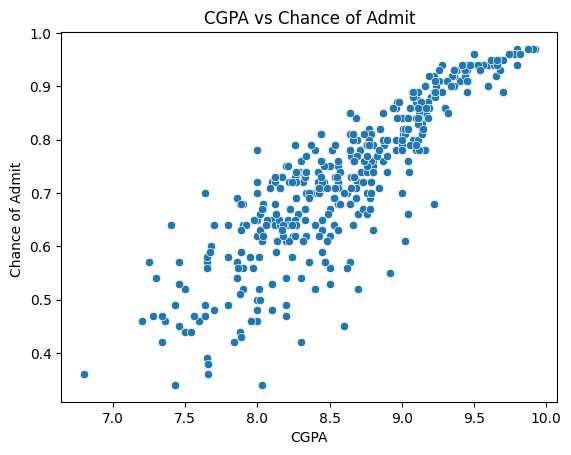

Epoch 1/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 3s 54ms/step - loss: 0.1795 - mae: 0.3686 - val_loss: 0.0738 - val_mae: 0.2294
Epoch 2/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.0702 - mae: 0.2108 - val_loss: 0.0630 - val_mae: 0.2028
Epoch 3/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.0343 - mae: 0.1455 - val_loss: 0.0259 - val_mae: 0.1281
Epoch 4/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.0223 - mae: 0.1186 - val_loss: 0.0261 - val_mae: 0.1266
Epoch 5/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.0164 - mae: 0.1013 - val_loss: 0.0184 - val_mae: 0.1040
Epoch 6/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.0124 - mae: 0.0839 - val_loss: 0.0156 - val_mae: 0.0945
Epoch 7/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0098 - mae: 0.0776 - val_loss: 0.0134 - val_mae: 0.0873
Epoch 8/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.0086 - mae: 0.0717 - val_loss: 0.0114 - val_mae: 0.0799
Epoch 9/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.0077 - mae: 

C:\Users\Arjun Singh Tomar\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


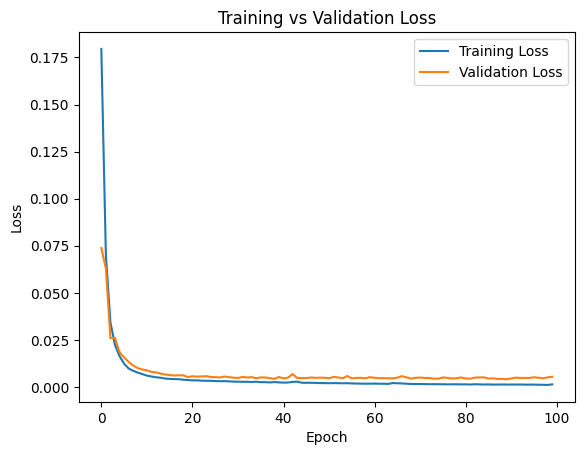

In [2]:
import pandas as pd
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score


# Load dataset
df = pd.read_csv(r'C:\\Users\\Arjun Singh Tomar\\Downloads\\archive (20)\\Admission_Predict.csv')


# Basic checking
print(df.head())
print(df.shape)
print(df.isnull().sum())
print(df.duplicated().sum())


# Remove unnecessary column
df = df.drop("Serial No.", axis=1)


# EDA
sns.histplot(df["Chance of Admit "], kde=True)
plt.title("Chance of Admit Distribution")
plt.show()


sns.scatterplot(
    x="CGPA",
    y="Chance of Admit ",
    data=df
)
plt.title("CGPA vs Chance of Admit")
plt.show()


# Features and target
X = df.drop("Chance of Admit ", axis=1)
y = df["Chance of Admit "]


# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)


# Scaling
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


# ANN
model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(X_train.shape[1],)),
    tf.keras.layers.Dense(64, activation="relu"),
    tf.keras.layers.Dense(32, activation="relu"),
    tf.keras.layers.Dense(16, activation="relu"),
    tf.keras.layers.Dense(1)
])


# Compile
model.compile(
    optimizer="adam",
    loss="mse",
    metrics=["mae"]
)


# Training
history = model.fit(
    X_train,
    y_train,
    epochs=100,
    batch_size=32,
    validation_split=0.1
)


# Evaluation
loss, mae = model.evaluate(
    X_test,
    y_test,
    verbose=0
)

print("Test Loss:", loss)
print("Test MAE:", mae)


# Prediction
y_pred = model.predict(X_test)


# Metrics
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("MSE:", mse)
print("RMSE:", rmse)
print("R2 Score:", r2)


# New student
new_student = np.array([[
    320,
    110,
    4,
    4.0,
    4.5,
    9.0,
    1
]])

new_student_scaled = scaler.transform(new_student)

prediction = model.predict(new_student_scaled)

print("Predicted Chance of Admit:", prediction[0][0])


# Loss graph
plt.plot(history.history["loss"])
plt.plot(history.history["val_loss"])

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend(["Training Loss", "Validation Loss"])
plt.show()